Leishmania major surface proteinase leishmanolysin and Palladium ligand Complex
======================


## ``Gromacs_py`` simulation

Here is an example of a short simulation of the protein PDB code (`1lml`) protein in complex with a specially prepared ligand containing a transition metal (`PDL`)using AMBER force-field model.

Need to do this to properly docked system. The PDB file of ligand was provided. The protein-ligand were docked together with `AMDock` using `Autodock4Zn` (1lml contains a Zinc finger). Details at [docking_report_claude_ligand_distortion](amdock_leishmaniasis_pdligand/docking_report_claude_ligand_distortion.md).
The protein and ligand were separated into different PDBs.

Note that this protein contains Zinc, which is included in the PDB as a HETATM, but needs to be ATOM. This was done manually. 

Error occursre because `pdb2gmx` expects a chain to contain residues of a single type (e.g., all Protein or all Ion). Since your ZN atom is currently at the end of Chain A, GROMACS sees a "Protein" chain ending with an "Ion".

To fix this, edit your 1lml_pdl.pdb file to insert a TER record before the Zinc line and ensure the Zinc line has a different chain ID (e.g., B) or no chain ID.


Also, spurious HETATM residues (probably from ligand) were remove manually.

Finally, nine successive steps are used:

1. Load the protein in its best -docked state. 
   
2. In-complex creation of Protein Topology using ``GmxSys.add_top()``, followed by boxing and solvation/neutralization.
   
3. Boxing of complex.
   
4. Since the ligand contains a transition metal with d-orbitals, standard ligand topology generators won't work. For instance, the `sqm` routine called by `acpype` does Hartree-Fock optimization only with bases containing $s,p$ orbitals as starting points, and $Pd$ has $d-$orbitals. So the best-docked pose had to be manually protonated and the topology generated using full Density Functional Theory software (I chose `gaussian-16`) and the partial charges of the atoms determined using `RESP` algorithm in `Multiwfn`. For details see [relevant README](ligand_topology_builder_claudeai_20260426/README.md).
   
5. Solvate complex and add ions.

6. Minimisation of the structure using ``GmxSys.em_2_steps()``.

7. Equilibration of the system using ``GmxSys.em_equi_three_step_iter_error()``.

8. Production run using ``GmxSys.production()``.
   
9.  Post-processing using `GmxSys.convert_trj().`

### Import

In [1]:
import sys
import os
import shutil

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#For vast.ai only
#os.environ["PATH"] = "/venv/main/bin.AVX2_256:/venv/main/bin:/opt/miniforge3/condabin:/opt/nvm/versions/node/v24.14.1/bin:" + os.environ["PATH"]

## To use `gromacs_py` in a project

In [3]:
from gromacs_py import gmx

## Simulation setup

- Define a few variables for you simulation, like:
  
    1. simulation output folders
    2. ionic concentration
    3. number of minimisation steps
    4. equilibration and production time

### Regarding equilibriation time:
The following variables define the sim times (relative units) for each stage of the three-stage equilibriation process. Check notes below for details:

1. `HA_time`
2. `CA_time`
3. `CA_LOW_time` 


In [4]:
DATA_OUT = '1lml_pdl_complex'

# System Setup
vsite='none'
sys_top_folder = os.path.join(DATA_OUT, 'sys_top')
#ignore_hydrogen = {'ignh': None}

# Energy Minimisation
em_folder = os.path.join(DATA_OUT, 'em')
em_sys_folder = os.path.join(DATA_OUT, 'sys_em')
em_step_number = 10000
emtol = 10.0  	# Stop minimization when the maximum force < 10 J/mol
emstep  = 0.01      # Energy step size


# Equillibration
equi_folder = os.path.join(DATA_OUT, 'sys_equi')
HA_time = 0.5
CA_time = 1.0
CA_LOW_time = 4.0

dt_HA = 0.001
dt = 0.002

HA_step = 1000 * HA_time / dt_HA
CA_step = 1000 * CA_time / dt
CA_LOW_step = 1000 * CA_LOW_time / dt

# Production
os.makedirs(DATA_OUT, exist_ok = True)
prod_folder = os.path.join(DATA_OUT, 'sys_prod')
#prod time in ns
prod_time = 10.0

prod_step = 1000 * prod_time / dt

## Create the `GmxSys` object

Load protein information only from docked PDB file on disk

In [5]:
%%script true

pdb_file = "1lml_pdl.pdb"
sys_name = "1lml_pdl_complex"
complex_sys = gmx.GmxSys(name=sys_name, coor_file=pdb_file)

## Create topology and stuff

1. Topology creation involves using `pdb2gmx` via the `prepare_top()` function.
   Since you have already manually cleaned the PDB and set Zinc to ATOM, you should bypass the internal pdb2pqr step and the "Zinc Finger" logic (which attempts to add Zinc automatically) by calling pdb2gmx directly via complex_sys.add_top(). This ensures GROMACS sees exactly what is in your PDB.
2. Create box



In [6]:
%%script true
complex_sys.add_top(DATA_OUT, name=sys_name, ff='amber99sb-ildn', water='tip3p', pdb2gmx_option_dict={'ignh': None})

gmx pdb2gmx -f ../1lml_pdl.pdb -o 1lml_pdl_complex_pdb2gmx.pdb -p 1lml_pdl_complex_pdb2gmx.top -i 1lml_pdl_complex_posre.itp -water tip3p -ff amber99sb-ildn -ignh


## Create Ligand topology and transclude manually to complex topology

Doing this automatically in `gromacs_py` is buggy and doesn't work, necessitating manual overrides.

1. Ligand topology was generated manualy using `DFT/RESP` (see above). Much like previous sims, it involved running `acpype`, but in a different way.

3. Next, copy-paste the contents of the ligand's amber force field topology file transclusions to the top of the complex topology file, AND the molecules section of the ligand's topology file to the molecules section of the complex topology file. 

**Note:** The ligand information MUST come FIRST in the complex topology, as there are new atomtypes in there and those must be defined first before any `moleculetype`. [See this](https://gromacs.bioexcel.eu/t/invalid-order-for-directive-atomtypes-error/3859)

4. Make sure to adjust the paths of all transcluded files.

5. Finally, update the complex PDB file with ligand co-ordinates from the best-docked pose using `pymol`.


# Zinc finger handling

`GROMACS` read the protein PDB, where `Zn` in the Zinc finger was presented as a separate atom. The resultant topology presented the `Zn` as a separate  "chain", which doesn't work (sims crash) because the Zinc is actually co-ordinated with amino acids in the finger. To resolve this, see the [Zinc README file](zinc_containing_prot_howto.md).


## Parallelization

Set parallelization and GPU options here. Change them later, if needed.

In [9]:
%%script true
#Parallelization
nthreads = int(os.environ.get('SLURM_CPUS_PER_TASK', '32'))
complex_sys.nt = nthreads
complex_sys.gpu_id = '0'
complex_sys.display()

name         : 1lml_pdl_complex
coor_file    : 1lml_pdl_complex/1lml_pdl_complex_pdb2gmx.pdb
top_file     : 1lml_pdl_complex/1lml_pdl_complex_pdb2gmx.top
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 0


In [10]:
%%script true
complex_sys.create_box(dist=1.5, box_type="dodecahedron", check_file_out=True)
complex_sys.solvate_add_ions(out_folder=DATA_OUT, name=sys_name,create_box_flag=False, maxwarn=4)
complex_sys.display()

gmx editconf -f 1lml_pdl_complex/1lml_pdl_complex_pdb2gmx.pdb -o 1lml_pdl_complex/1lml_pdl_complex_pdb2gmx_box.pdb -bt dodecahedron -d 1.5
gmx grompp -f ../../../../../../venv/main/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp -c 1lml_pdl_complex_water.pdb -r 1lml_pdl_complex_water.pdb -p 1lml_pdl_complex_water_ion.top -po out_mini.mdp -o genion_1lml_pdl_complex_water_ion.tpr -maxwarn 4
gmx genion -s genion_1lml_pdl_complex_water_ion.tpr -p 1lml_pdl_complex_water_ion.top -o 1lml_pdl_complex_water_ion.gro -np 65 -pname NA -nn 54 -nname CL
name         : 1lml_pdl_complex
sim_name     : genion_1lml_pdl_complex_water_ion
coor_file    : 1lml_pdl_complex/1lml_pdl_complex_water_ion.gro
top_file     : 1lml_pdl_complex/1lml_pdl_complex_water_ion.top
tpr          : 1lml_pdl_complex/genion_1lml_pdl_complex_water_ion.tpr
mdp          : ../../../../../venv/main/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_histo

## Add index groups

Now, we have to add the following index groups: Merge the Protein with the ligand (PDL) with the shell command

```bash
gmx make_ndx -f 1lml_pdl_complex_water_ion.gro -o 1lml_pdl_complex_water_ion.ndx
```
Merge group 1 with group 15 to form `Protein_PDL` group. We can now set temperature control groups to = `Protein_PDL` and `Water_and_ions` later.

Finally, add the index file to the `complex_sys` object.

In [11]:
%%script true
complex_sys.add_ndx("",ndx_name="1lml_pdl_complex_water_ion", folder_out=DATA_OUT)

In [12]:
%%script true
complex_sys.display()

name         : 1lml_pdl_complex
sim_name     : genion_1lml_pdl_complex_water_ion
coor_file    : 1lml_pdl_complex/1lml_pdl_complex_water_ion.gro
top_file     : 1lml_pdl_complex/1lml_pdl_complex_water_ion.top
tpr          : 1lml_pdl_complex/genion_1lml_pdl_complex_water_ion.tpr
ndx          : 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx
mdp          : ../../../../../venv/main/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 0


In [13]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.start_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## From here, run in cluster
### System energy minimisation and equilibration

Based on `gromacs_py` docs, this is a 3-stage equilibriation process. 

All three steps seem to be NPT with berendsen coupling and v-rescale for temp coupling. Each step just has different restraints. This does not seem so bad: closer to lab conditions.

Since the statistical ensemble is pretty much always NPT, this is different from the Lemkul-lysozyme tutorial at [MDTutorials](http://www.mdtutorials.com/gmx/lysozyme/).

**Note:** 
1. Had to run this on cluster at least. Too slow even in ofc workstn.
2. Temperature coupling groups have to be set properly. See [mdtutorials](http://www.mdtutorials.com/gmx/complex/06_equil.html) and [gromacs-py manual](https://gromacs-py.readthedocs.io/en/latest/notebook/01_dna_ligand_ambertools.html#System-equilibration)
3. Ligand name is `PDL` as seen in the index file by visual inspection.

In [27]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.start_20260429.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

# Note: May need to adjust some paths in the object.

In [28]:
%%script true
complex_sys.display()

name         : 1lml_pdl_complex
sim_name     : genion_1lml_pdl_complex_water_ion
coor_file    : 1lml_pdl_complex/1lml_pdl_complex_water_ion.gro
top_file     : 1lml_pdl_complex/1lml_pdl_complex_water_ion.top
tpr          : 1lml_pdl_complex/genion_1lml_pdl_complex_water_ion.tpr
ndx          : 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx
mdp          : ../../../../../venv/main/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 0


In [29]:
%%script true
# Energy minimization and equilibration

complex_sys.em_equi_three_step_iter_error(
    out_folder=equi_folder,
    no_constr_nsteps=em_step_number,
    constr_nsteps=em_step_number,
    nsteps_HA=HA_step,  
    nsteps_CA=CA_step,
    nsteps_CA_LOW=CA_LOW_step,
    dt=dt, dt_HA=dt_HA,
    tc_grps='Protein_PDL Water_and_ions',
    tau_t= '0.1 0.1',
    ref_t= '310 310',
    vsite=vsite, 
    maxwarn=10, 
    iter_num=1,
    monitor_tool=None
)#Progressbar is buggy, so set monitor_tool to none. 

In [ ]:
%%script true
complex_sys.display()

name         : 1lml_pdl_complex
sim_name     : equi_CA_LOW_1lml_pdl_complex
coor_file    : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.gro
top_file     : 1lml_pdl_complex/1lml_pdl_complex_water_ion.top
tpr          : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.tpr
ndx          : 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx
mdp          : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.mdp
xtc          : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.xtc
edr          : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.edr
log          : 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.log
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 5


In [31]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Load Checkpoint

In [24]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_20260429.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

# Note: May need to adjust some paths in the object.
complex_sys.display()

name         : 1lml_pdl_complex
sim_name     : equi_CA_LOW_1lml_pdl_complex
coor_file    : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.gro
top_file     : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/1lml_pdl_complex_water_ion.top
tpr          : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.tpr
ndx          : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx
mdp          : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.mdp
xtc          : ../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.xt

### Change the path prefixed to match running system

In [ ]:
%%script true

# Define the prefix to remove
old_prefix = "../../../../admin/gitrepos/gromacs_sims/protein-1lml-ligand-pdl-sim/"

# Update main object paths
complex_sys.coor_file = complex_sys.coor_file.replace(old_prefix, "")
complex_sys.top_file = complex_sys.top_file.replace(old_prefix, "")
complex_sys.tpr = complex_sys.tpr.replace(old_prefix, "")
complex_sys.ndx = complex_sys.ndx.replace(old_prefix, "")
complex_sys.mdp = complex_sys.mdp.replace(old_prefix, "")
complex_sys.xtc = complex_sys.xtc.replace(old_prefix, "")
complex_sys.edr = complex_sys.edr.replace(old_prefix, "")
complex_sys.log = complex_sys.log.replace(old_prefix, "")

# Update history paths if necessary
for hist in complex_sys.sys_history:
    hist.coor_file = hist.coor_file.replace(old_prefix, "")
    hist.top_file = hist.top_file.replace(old_prefix, "")
    hist.tpr = hist.tpr.replace(old_prefix, "")
    hist.ndx = hist.ndx.replace(old_prefix, "")
    try:
        hist.mdp = hist.mdp.replace(old_prefix, "")
    except:
        pass
    if hist.xtc is not None:
        hist.xtc = hist.xtc.replace(old_prefix, "")
    if hist.edr is not None:
        hist.edr = hist.edr.replace(old_prefix, "")
    if hist.log is not None:
        hist.log = hist.log.replace(old_prefix, "")

## Plot energy:

gmx energy -f 1lml_pdl_complex/sys_equi/sys_em/Init_em_1lml_pdl_complex.edr -o tmp_edr.xvg
gmx energy -f 1lml_pdl_complex/sys_equi/sys_em/1lml_pdl_complex.edr -o tmp_edr.xvg


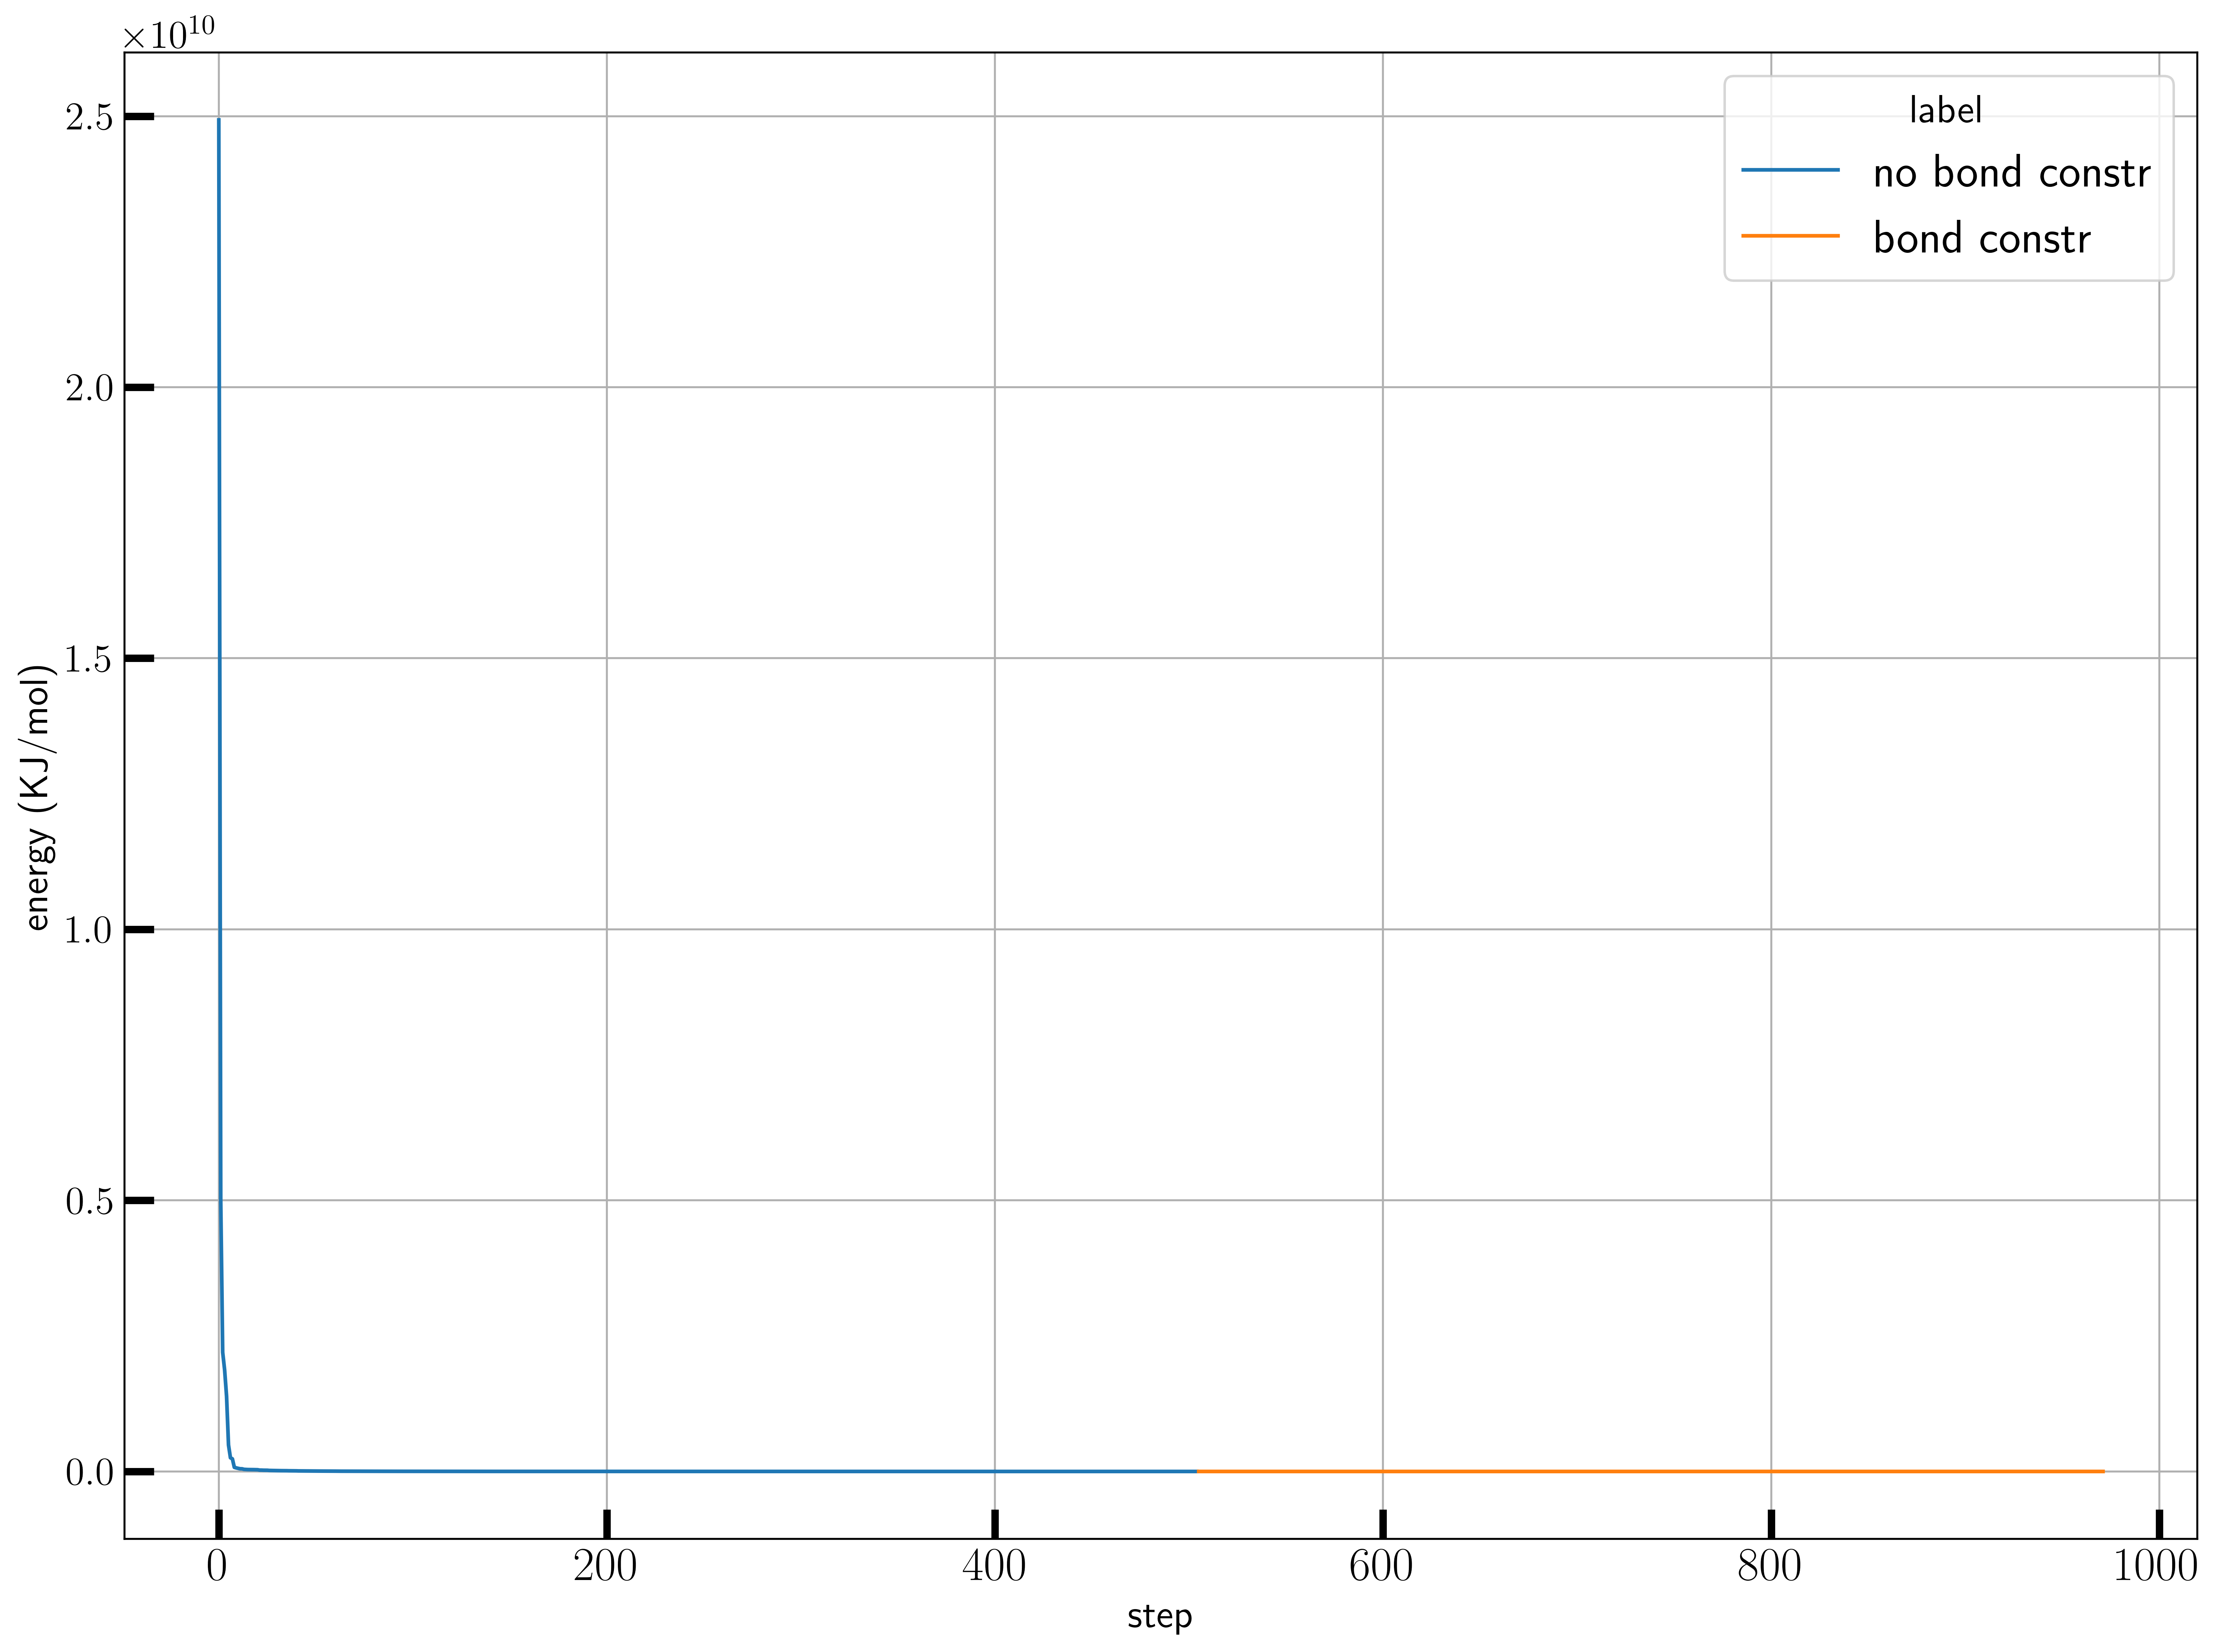

In [26]:
%%script true
# Verify the indices first
ener_pd_1 = complex_sys.sys_history[-4].get_ener(selection_list=['Potential'])
ener_pd_2 = complex_sys.sys_history[-3].get_ener(selection_list=['Potential'])

ener_pd_1['label'] = 'no bond constr'
ener_pd_2['label'] = 'bond constr'

ener_pd = pd.concat([ener_pd_1, ener_pd_2])

ener_pd['Time (ps)'] = np.arange(len(ener_pd))
ax = sns.lineplot(x="Time (ps)", y="Potential",
        hue="label",
        data=ener_pd)
ax.set_xlabel('step')
ax.set_ylabel('energy (KJ/mol)')
plt.grid()

### Plot Equilibriation

Since the statistical ensemble is pretty much always NPT, this is different from the Lemkul-lysozyme tutorial at [MDTutorials](http://www.mdtutorials.com/gmx/lysozyme/). So we need to see Volume as well as Pressure, temperature, and density.

In [27]:
%%script true
quantities = ["Temperature", "Pressure", "Volume", "Density"]
units = ["$K$", "$bar$", "$A^3$", "$kg/m^3$"]

pd_1 = complex_sys.sys_history[-2].get_ener(selection_list=quantities)
pd_2 = complex_sys.sys_history[-1].get_ener(selection_list=quantities)
pd_3 = complex_sys.get_ener(selection_list=quantities)

pd_1['label'] = 'HA_constr'
pd_2['label'] = 'CA_constr'
pd_2['Time (ps)'] = pd_2['Time (ps)'] + pd_1['Time (ps)'].max()
pd_3['label'] = 'CA_LOW_constr'
pd_3['Time (ps)'] = pd_3['Time (ps)'] + pd_2['Time (ps)'].max()

display(pd.concat([pd_1, pd_2, pd_3]))

gmx energy -f 1lml_pdl_complex/sys_equi/sys_equi/00_equi_HA/equi_HA_1lml_pdl_complex.edr -o tmp_edr.xvg
gmx energy -f 1lml_pdl_complex/sys_equi/sys_equi/01_equi_CA/equi_CA_1lml_pdl_complex.edr -o tmp_edr.xvg
gmx energy -f 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.edr -o tmp_edr.xvg


,Time (ps),Temperature,Pressure,Volume,Density,label
0,0.0,0.056736,-3813.385498,803.918579,1003.765808,HA_constr
1,5.0,311.634735,274.389679,802.561646,1005.462891,HA_constr
2,10.0,309.913239,-222.669235,801.144592,1007.241333,HA_constr
3,15.0,310.952789,-109.199654,799.487061,1009.329590,HA_constr
4,20.0,309.686371,115.605644,797.797424,1011.467224,HA_constr
...,...,...,...,...,...,...
396,5460.0,309.903503,103.158348,794.041138,1016.252075,CA_LOW_constr
397,5470.0,308.810577,-165.713242,795.299866,1014.643677,CA_LOW_constr
398,5480.0,308.813873,-108.667664,800.431519,1008.138672,CA_LOW_constr
399,5490.0,310.649078,-43.486053,794.834351,1015.237915,CA_LOW_constr


In [ ]:
%%script true
plt.rcParams.update({'font.size': 22})

fig, axs = plt.subplots(4, 1, figsize=(24,13.5), sharex=True, tight_layout=True)

for ax, quantity, unit in zip(axs, quantities, units):
    for df in (pd_1, pd_2, pd_3):
        ax.plot(df["Time (ps)"], df[quantity], label=str(df['label'][0]))
        ax.set_ylabel(quantity + "(" + unit + ")")
        ax.grid()

axs[0].legend()
axs[-1].set_xlabel("Time (ps)");

Looks okay to me. Fluctuations are high at the end because CA constraints are low, but there is a well-defined average.

### Plot RMSD

In [29]:
%%script true
# Define reference structure for RMSD calculation
ref_sys =  complex_sys.sys_history[1]
struct="Protein"

rmsd_pd_1 = complex_sys.sys_history[-2].get_rmsd([struct, struct], ref_sys=ref_sys)
rmsd_pd_2 = complex_sys.sys_history[-1].get_rmsd([struct, struct], ref_sys=ref_sys)
rmsd_pd_3 = complex_sys.get_rmsd([struct, struct], ref_sys=ref_sys)


rmsd_pd_1['label'] = 'HA_constr'
rmsd_pd_2['label'] = 'CA_constr'
rmsd_pd_2['time'] = rmsd_pd_2['time'] + rmsd_pd_1['time'].max()
rmsd_pd_3['label'] = 'CA_LOW_constr'
rmsd_pd_3['time'] = rmsd_pd_3['time'] + rmsd_pd_2['time'].max()

display(pd.concat([rmsd_pd_1, rmsd_pd_2, rmsd_pd_3]))


gmx rms -s 1lml_pdl_complex/sys_equi/sys_em/Init_em_1lml_pdl_complex.tpr -f 1lml_pdl_complex/sys_equi/sys_equi/00_equi_HA/equi_HA_1lml_pdl_complex.xtc -n 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx -o tmp_rmsd.xvg -fit rot+trans -ng 1 -pbc no
gmx rms -s 1lml_pdl_complex/sys_equi/sys_em/Init_em_1lml_pdl_complex.tpr -f 1lml_pdl_complex/sys_equi/sys_equi/01_equi_CA/equi_CA_1lml_pdl_complex.xtc -n 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx -o tmp_rmsd.xvg -fit rot+trans -ng 1 -pbc no
gmx rms -s 1lml_pdl_complex/sys_equi/sys_em/Init_em_1lml_pdl_complex.tpr -f 1lml_pdl_complex/sys_equi/sys_equi/02_equi_CA_LOW/equi_CA_LOW_1lml_pdl_complex.xtc -n 1lml_pdl_complex/1lml_pdl_complex_water_ion.ndx -o tmp_rmsd.xvg -fit rot+trans -ng 1 -pbc no


,time,Protein,label
0,0.0,1.480655,HA_constr
1,5.0,1.485333,HA_constr
2,10.0,1.510903,HA_constr
3,15.0,1.558567,HA_constr
4,20.0,1.536776,HA_constr
...,...,...,...
396,5460.0,1.639893,CA_LOW_constr
397,5470.0,1.589089,CA_LOW_constr
398,5480.0,1.580341,CA_LOW_constr
399,5490.0,1.632774,CA_LOW_constr


In [ ]:
%%script true
fig, ax = plt.subplots(1, 1, figsize=(24,13.5))

for df in (rmsd_pd_1, rmsd_pd_2, rmsd_pd_3):
        ax.plot(df["time"], df["Protein"], label=str(df['label'][0]))
        ax.set_ylabel(quantity + "(" + unit + ")")
        
ax.set_title(struct)
ax.set_ylabel('RMSD (nm)')
ax.set_xlabel('Time (ps)')
plt.grid()

## Report on Equilibration

I reviewed the cleaned equilibration video together with the supplied structures. The `.xtc` files were centered (protein) with `pbc` artifacts removed  and fitted, all using `gmx trjconv`.

### Bottom-line assessment

* **Protein fold remains intact**
* **No obvious global unfolding**
* **Zinc remains in the pocket region**
* **Ligand is mobile and reorients significantly**
* **Ligand does not appear to fully diffuse into solvent during this clip**

So the system is **not obviously failing**, but the ligand is clearly **not rigidly locked in the original docked pose**.

---

### What I Observed

#### 1. Protein stability: Good

Across the trajectory:

* overall tertiary structure remains compact
* loops fluctuate normally
* no major collapse
* no runaway sidechain explosions

This is what you want during equilibration.

---

#### 2. Zinc behavior: Acceptable / likely normal

The gray Zn sphere remains localized in the binding-site region.

I do **not** see:

* Zn ejecting into solvent
* Zn drifting several Å away
* pocket collapse around Zn

Some frame-to-frame motion is normal thermal fluctuation.

##### Interpretation

My Zn bonded-coordination patch appears to be doing its job.

---

#### 3. Ligand behavior: Significant pose relaxation

The ligand (Pd complex) clearly changes orientation and shifts position over time.

It appears to:

* pivot
* slide deeper / laterally within cavity
* sample multiple conformations

That usually means one of two things:

##### Benign scenario

Docking pose was approximate, MD is relaxing into a more realistic bound pose.

##### Concerning scenario

Ligand is weakly bound and beginning to leave.

From this video, it looks more like **pose rearrangement than full dissociation**.

---

### Important Chemical Context

The ligand is **not a simple organic ligand** — it is a **Pd-containing coordination complex**.

That matters because:

* classical force fields can model flexibility imperfectly
* docking scores for metal complexes are often unreliable
* binding orientation can change substantially in MD

So seeing motion is not automatically bad.

---

### What Looks Encouraging

#### Ligand remains pocket-associated

Even after substantial movement, it still appears associated with the protein cavity rather than escaping into bulk solvent.

That suggests there is still attractive interaction.

#### Zn and ligand coexist in same site region

No dramatic repulsion event.

---

#### Suggested metric:

Measure center-of-mass distance between ligand and nearby binding residues.

If stable: still bound.

---

##### Priority Analysis 3 — Contacts / H-bonds

Check if the ligand forms persistent contacts with:

* hydrophobic pocket residues
* H-bonds
* π interactions
* metal-proximal residues

---

##### Priority Analysis 4 — Zn coordination distances

Track:

* Zn–His distances
* Zn–water if relevant
* Zn–ligand donor atom if expected

If Zn distances remain stable, your metallosite is healthy.

---

### My Interpretation of the Docking Pose

The original docked pose was probably **over-constrained / optimistic**.

This is common. Docking often places ligands in:

* strained orientations
* no explicit solvent
* rigid receptor assumptions

MD then relaxes to something more physical.

---

### My Practical Verdict

#### Protein: stable

#### Zinc site: stable enough

#### Ligand: mobile but still plausibly bound

#### Simulation quality: usable and worth continuing

This does **not** look like a failed equilibration.

It looks like a system relaxing away from a rigid docking pose.

---

### Next Step

Run **10 ns production test** now and monitor ligand COM distance.

If ligand stays in cavity for 10 ns, you likely have a real metastable bound state.

---


### Save production-ready checkpoint with relative paths

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_prodready_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Production MD 

tc-coupling groups are required here as well. See [gromacs-py manual](https://gromacs-py.readthedocs.io/en/latest/notebook/01_dna_ligand_ambertools.html#Production)

In [1]:
#%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_prodready_20260429.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

## Update paths in object

In the imported object complex_sys (and history), the path `/home/daneel` needs to be changed to `/home/arunima`

In [ ]:
#%%script true
old_path = "/home/daneel"
new_path = "/home/arunima"

# Update main object paths
complex_sys.coor_file = complex_sys.coor_file.replace(old_path, new_path)
complex_sys.top_file = complex_sys.top_file.replace(old_path, new_path)
complex_sys.tpr = complex_sys.tpr.replace(old_path, new_path)
complex_sys.ndx = complex_sys.ndx.replace(old_path, new_path)
complex_sys.mdp = complex_sys.mdp.replace(old_path, new_path)
complex_sys.xtc = complex_sys.xtc.replace(old_path, new_path)
complex_sys.edr = complex_sys.edr.replace(old_path, new_path)
complex_sys.log = complex_sys.log.replace(old_path, new_path)


for hist in complex_sys.sys_history:
    hist.coor_file = hist.coor_file.replace(old_path, new_path)
    hist.top_file = hist.top_file.replace(old_path, new_path)
    hist.tpr = hist.tpr.replace(old_path, new_path)
    hist.ndx = hist.ndx.replace(old_path, new_path)
    try:
        hist.mdp = hist.mdp.replace(old_path, new_path)
    except:
        pass
    if hist.xtc is not None:
        hist.xtc = hist.xtc.replace(old_path, new_path)
    if hist.edr is not None:
        hist.edr = hist.edr.replace(old_path, new_path)
    if hist.log is not None:
        hist.log = hist.log.replace(old_path, new_path)

In [ ]:
#%%script true
#Parallelization
nthreads = int(os.environ.get('PBS_NCPUS', '32'))

#Set Parallelization
complex_sys.nt = nthreads
#complex_sys.ntmpi = 1
complex_sys.gpu_id = '0'

complex_sys.production(out_folder=prod_folder,
        nsteps=prod_step,
        tc_grps='Protein_PDL Water_and_ions',
        tau_t= '0.1 0.1',
        ref_t= '310 310',
        dt=dt, vsite=vsite, maxwarn=1, nstlist=200, monitor_tool=None)

## Checkpointing for extending


In [ ]:
#%%script true
import pickle, datetime
chkpt_fname='checkpoint.prod_' + datetime.date.today().strftime("%Y%m%d") + '.pycpt'
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Post-Production

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.prod_20250122.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

## Extend simulation
Just out of curiosity, extend the simulation time to $50\; ns$ after a default run of $10\; ns$.

In [ ]:
%%script true
complex_sys.extend_sim(tpr_file=complex_sys.tpr, nsteps=prod_step)

### Prepare Production Trajectory for Viewing

#### Center Trajectory

In [ ]:
#%%script true
# Center trajectory
complex_sys.center_mol_box(traj=True)

## Final Steps
As in any simulation conducted with periodic boundary conditions, molecules may appear "broken" or may "jump" back and forth across the box. To recenter the protein and rewrap the molecules within the unit cell to recover the desired box shape, invoke trjconv. 

Choose "Protein" for centering and "System" for output.

In [ ]:
#%%script true
complex_sys.convert_trj(select='Protein\nSystem', fit='rot+trans', pbc='none')

#### Extract production initial condition
Optionally, extract the first frame of the final prod traj (latest from history, as the running one got updated) into a `pdb` for loading into post processing.

In [ ]:
#%%script true
complex_sys.sys_history[-1].convert_trj(select='Protein\nSystem', fit='rot+trans', pbc='none', specific_coor_out=prod_folder+"/start.pdb", dump="0")